# Adaptive Window Grid Search — a=0.3, b=80, delta=1 only (v2)

Grid search over `(w_min, w_max)` for **BOCPD + adaptive OLS** on:
- `initial_value_5_samples_500_a_0.3_b_80_delta_1.csv` (Z0=5)
- `initial_value_80_samples_500_a_0.3_b_80_delta_1.csv` (Z0=80)

Uses rolling-std / running-std-max adaptive window sizing from `v2/ablation_study_wider_adaptive.py`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import itertools
import warnings
import statsmodels.api as sm
warnings.filterwarnings('ignore')

V2_DIR = '/Users/qianxinhui/Desktop/Misc/2026/NU-Research/kellogg/change-point-detection/v2'
os.chdir(V2_DIR)
import sys
sys.path.insert(0, V2_DIR)

from src.booles_cpd_predictor import BOOLES_cpdPredictor
from src.pmf import transient_distribution_piecewise
from src import calculate_kl_divergence, load_histogram

ARRIVAL_DIR = os.path.join(V2_DIR, 'data_integrated/arrival_data')
HIST_DIR = os.path.join(V2_DIR, '..', 'data_integrated/Simulation_histograms')
SAVE_DIR = os.path.join(V2_DIR, 'results/adaptive_grid_a03_b80')
os.makedirs(SAVE_DIR, exist_ok=True)


In [2]:
# --- Adaptive prediction (rolling-std / running-std-max window) ---
def run_adaptive(df, mu, t_target, m=1, N=80, ws_min=2, ws_max=50,
                 lookback=30, bocpd_params=None):
    """
    BOCPD + adaptive-window OLS prediction.
    Window size: ws_t = ws_min + (ws_max - ws_min) * (1 - v_t)
    where v_t = rolling_std[t] / running_std_max[t]
    """
    values = df['value'].values
    times = df['time'].values
    n = len(values)
    mu0 = float(np.mean(values[:min(10, n)]))

    # BOCPD
    bp = bocpd_params or {}
    predictor = BOOLES_cpdPredictor(
        hazard_lambda=bp.get('hazard_lambda', 100),
        mu0=bp.get('mu0', mu0),
        kappa0=bp.get('kappa0', 1.0),
        alpha0=bp.get('alpha0', 2.0),
        beta0=bp.get('beta0', 5.0),
        alarm_threshold=bp.get('alarm_threshold', 0.1),
    )
    cp_probs = np.array([predictor.update_bocpd_online(v) for v in values])

    # Rolling std + running max
    rolling_std = np.zeros(n)
    running_std_max = np.zeros(n)
    for i in range(n):
        start = max(0, i - lookback)
        rolling_std[i] = np.std(values[start:i+1]) if i > 0 else 1.0
        running_std_max[i] = max(rolling_std[i],
                                  running_std_max[i-1] if i > 0 else 0.0)

    def get_ws(i):
        sm_ = running_std_max[i] if running_std_max[i] > 0 else 1.0
        v_t = rolling_std[i] / sm_
        ws = int(ws_min + (ws_max - ws_min) * (1 - v_t))
        return max(ws_min, min(ws, ws_max))

    # Walk with adaptive windows
    predicted = np.full(n, np.nan)
    stepwise = np.full(n, np.nan)
    ws_used = np.zeros(n, dtype=int)

    init_ws = get_ws(0)
    if init_ws * 2 > n:
        init_ws = max(2, n // 4)
    iw = df.iloc[:init_ws]
    ols_model = sm.OLS(iw['value'], sm.add_constant(iw['time'])).fit()

    predicted[:init_ws] = values[:init_ws].mean()
    stepwise[:init_ws] = values[:init_ws].mean()
    ws_used[:init_ws] = init_ws

    cursor = init_ws
    cp_threshold = bp.get('alarm_threshold', 0.1)
    all_dev = []

    while cursor < n:
        ws = get_ws(cursor)
        ws = max(ws_min, min(ws, n // 4))
        if ws < 2:
            ws = 2
        ps, pe = cursor, min(cursor + ws, n)
        pidx = np.arange(ps, pe)

        X_p = sm.add_constant(times[pidx])
        try:
            pred_vals = ols_model.predict(X_p)
            predicted[pidx] = pred_vals
            stepwise[pidx] = np.mean(pred_vals)
        except Exception:
            predicted[pidx] = values[pidx].mean()
            stepwise[pidx] = values[pidx].mean()
        ws_used[pidx] = ws

        if pe > ps:
            max_cp = cp_probs[ps:pe].max()
            if max_cp > cp_threshold:
                all_dev.append(ps)
                rw = np.arange(ps, pe)
                if len(rw) >= 2:
                    try:
                        ols_model = sm.OLS(values[rw], sm.add_constant(times[rw])).fit()
                    except Exception:
                        pass
            else:
                last = all_dev[-1] if all_dev else 0
                rw = np.arange(last, pe)
                if len(rw) >= 2:
                    try:
                        ols_model = sm.OLS(values[rw], sm.add_constant(times[rw])).fit()
                    except Exception:
                        pass
        cursor = pe

    # Metrics
    valid = ~np.isnan(predicted)
    preds, acts = predicted[valid], values[valid]
    errors = preds - acts
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors**2)

    return {
        'mse': mse, 'rmse': rmse, 'mae': mae,
        'mean_ws': float(ws_used[ws_used > 0].mean()) if (ws_used > 0).any() else 0,
        'n_steps': int((ws_used > 0).sum()),
        'stepwise': stepwise, 'predicted': predicted,
        'times': times, 'values': values,
        'ws_used': ws_used, 'cp_probs': cp_probs,
    }


def load_sim_hist(z0, t_obs):
    """Load simulation histogram, return (bin_centers, probabilities, widths)."""
    mu = 10 if z0 == 5 else 100
    hist_file = os.path.join(HIST_DIR,
        f"for_histogram_CoxM1_Z0{z0}_serv{mu}_t{int(t_obs)}.pickle")
    hist_data = load_histogram(hist_file)
    bins, counts = hist_data['bins'], hist_data['counts']
    centers = (bins[:-1] + bins[1:]) / 2
    widths = np.diff(bins)
    s = counts.sum()
    probs = counts / s if s > 0 else counts
    return centers, probs, widths


def compute_pmf_kl(result, z0, t_obs, N=300):
    """Compute predicted PMF and KL vs simulation."""
    mu = 10 if z0 == 5 else 100
    sw = result['stepwise'].copy()
    sw[np.isnan(sw)] = np.nanmean(sw)
    sw = np.maximum(sw, 1e-6)
    dt = np.diff(result['times'], prepend=result['times'][0])
    dt[dt <= 0] = 0.05
    t_max = dt.sum()
    t_use = min(t_obs, t_max * 0.99)
    try:
        pmf_pred = transient_distribution_piecewise(sw, dt, mu=mu, m=1, t=t_use, N=N)
        centers, probs, _ = load_sim_hist(z0, t_obs)
        sim_on_grid = np.zeros(len(pmf_pred))
        for c, p in zip(centers, probs):
            idx = int(round(c))
            if 0 <= idx < len(sim_on_grid): sim_on_grid[idx] += p
        kl = calculate_kl_divergence(sim_on_grid, pmf_pred)
        return kl, pmf_pred
    except Exception as e:
        print(f"  PMF error (z0={z0}, t={t_obs}): {e}")
        return np.nan, None


In [14]:
# --- Grid search configuration ---
W_MINS = [3, 4]
W_MAXS = [8, 10]
LOOKBACK = 30

BOCPD_PARAMS = dict(
    hazard_lambda=100,
    mu0=80.0, kappa0=1.0, alpha0=2.0, beta0=5.0,
    alarm_threshold=0.01,
)

all_files = [
    ('initial_value_5_samples_500_a_0.3_b_80_delta_1.csv', 5),
    ('initial_value_80_samples_500_a_0.3_b_80_delta_1.csv', 80),
]
print(f'Target files: {len(all_files)}')
for f, z0 in all_files:
    print(f'  Z0={z0}: {f}')


Target files: 2
  Z0=5: initial_value_5_samples_500_a_0.3_b_80_delta_1.csv
  Z0=80: initial_value_80_samples_500_a_0.3_b_80_delta_1.csv


In [15]:
# --- Run grid search (adaptive, rolling-std window) ---
results = []
total = len(all_files) * len(W_MINS) * len(W_MAXS)
count = 0

for file, z0 in all_files:
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    mu = 10 if z0 == 5 else 100

    for w_min, w_max in itertools.product(W_MINS, W_MAXS):
        count += 1
        tag = f'Z0={z0} | w_min={w_min}, w_max={w_max}'
        if count % 5 == 0 or count == 1:
            print(f'[{count}/{total}] {tag}')

        try:
            res = run_adaptive(data_raw.copy(), mu=mu, t_target=5, m=1, N=300,
                               ws_min=w_min, ws_max=w_max,
                               lookback=LOOKBACK, bocpd_params=BOCPD_PARAMS)

            kl_t1, _ = compute_pmf_kl(res, z0, t_obs=1)
            kl_t5, _ = compute_pmf_kl(res, z0, t_obs=5)

            results.append({
                'file': file, 'z0': z0,
                'w_min': w_min, 'w_max': w_max,
                'mse': res['mse'], 'rmse': res['rmse'], 'mae': res['mae'],
                'avg_window_size': res['mean_ws'],
                'n_steps': res['n_steps'],
                'kl_t1': kl_t1, 'kl_t5': kl_t5,
            })
        except Exception as e:
            print(f'  ERROR: {tag} -> {e}')
            results.append({
                'file': file, 'z0': z0,
                'w_min': w_min, 'w_max': w_max,
                'mse': np.nan, 'rmse': np.nan, 'mae': np.nan,
                'avg_window_size': np.nan, 'n_steps': np.nan,
                'kl_t1': np.nan, 'kl_t5': np.nan,
            })

print(f'\nDone! {len(results)} runs completed.')


[1/8] Z0=5 | w_min=3, w_max=8
[5/8] Z0=80 | w_min=3, w_max=8

Done! 8 runs completed.


In [16]:
# --- Build results DataFrame ---
df = pd.DataFrame(results)
df.to_csv(os.path.join(SAVE_DIR, 'adaptive_grid_results.csv'), index=False)
print(f'Results shape: {df.shape}')
df


Results shape: (8, 11)


,file,z0,w_min,w_max,mse,rmse,mae,avg_window_size,n_steps,kl_t1,kl_t5
0,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,3,8,8.245555,2.871507,2.113041,4.788423,501,0.713623,0.013279
1,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,3,10,7.567620,2.750931,2.046907,5.686627,501,0.711782,0.003497
2,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,4,8,7.715178,2.777621,2.063275,5.347305,501,0.702588,0.004926
3,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,4,10,8.917473,2.986214,2.168769,6.199601,501,0.702588,0.006824
4,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,3,8,10.836501,3.291884,2.464982,4.716567,501,0.674707,0.677417
5,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,3,10,14.086347,3.753178,2.877883,5.626747,501,0.676696,0.674732
6,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,4,8,10.178720,3.190411,2.422821,5.307385,501,0.674195,0.664475
7,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,4,10,8.182601,2.860525,2.161185,6.081836,501,0.674033,0.670977


In [17]:
# --- Summary: Mean metrics by (w_min, w_max) ---
summary = df.groupby(['w_min', 'w_max']).agg(
    mse_mean=('mse', 'mean'), mse_std=('mse', 'std'),
    mae_mean=('mae', 'mean'),
    avg_ws_mean=('avg_window_size', 'mean'),
    kl_t1_mean=('kl_t1', 'mean'),
    kl_t5_mean=('kl_t5', 'mean'),
).reset_index().sort_values('kl_t5_mean')

print('=== Overall Summary (sorted by KL@t=5) ===')
summary


=== Overall Summary (sorted by KL@t=5) ===


,w_min,w_max,mse_mean,mse_std,mae_mean,avg_ws_mean,kl_t1_mean,kl_t5_mean
2,4,8,8.946949,1.741987,2.243048,5.327345,0.688392,0.334700
3,4,10,8.550037,0.519633,2.164977,6.140719,0.688311,0.338901
1,3,10,10.826984,4.609437,2.462395,5.656687,0.694239,0.339115
0,3,8,9.541028,1.832075,2.289011,4.752495,0.694165,0.345348


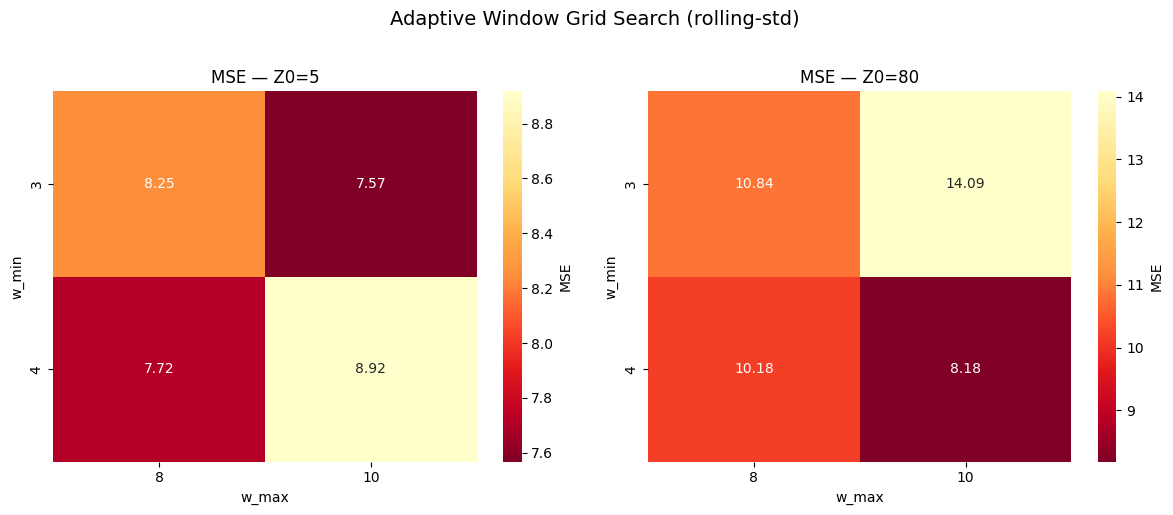

In [18]:
# --- Heatmap: MSE by (w_min, w_max) — split by Z0 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, z0_val in zip(axes, [5, 80]):
    sub = df[df['z0'] == z0_val].groupby(['w_min', 'w_max'])['mse'].mean().reset_index()
    pivot = sub.pivot(index='w_min', columns='w_max', values='mse')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
                cbar_kws={'label': 'MSE'})
    ax.set_title(f'MSE — Z0={z0_val}')
    ax.set_xlabel('w_max'); ax.set_ylabel('w_min')
plt.suptitle('Adaptive Window Grid Search (rolling-std)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mse_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


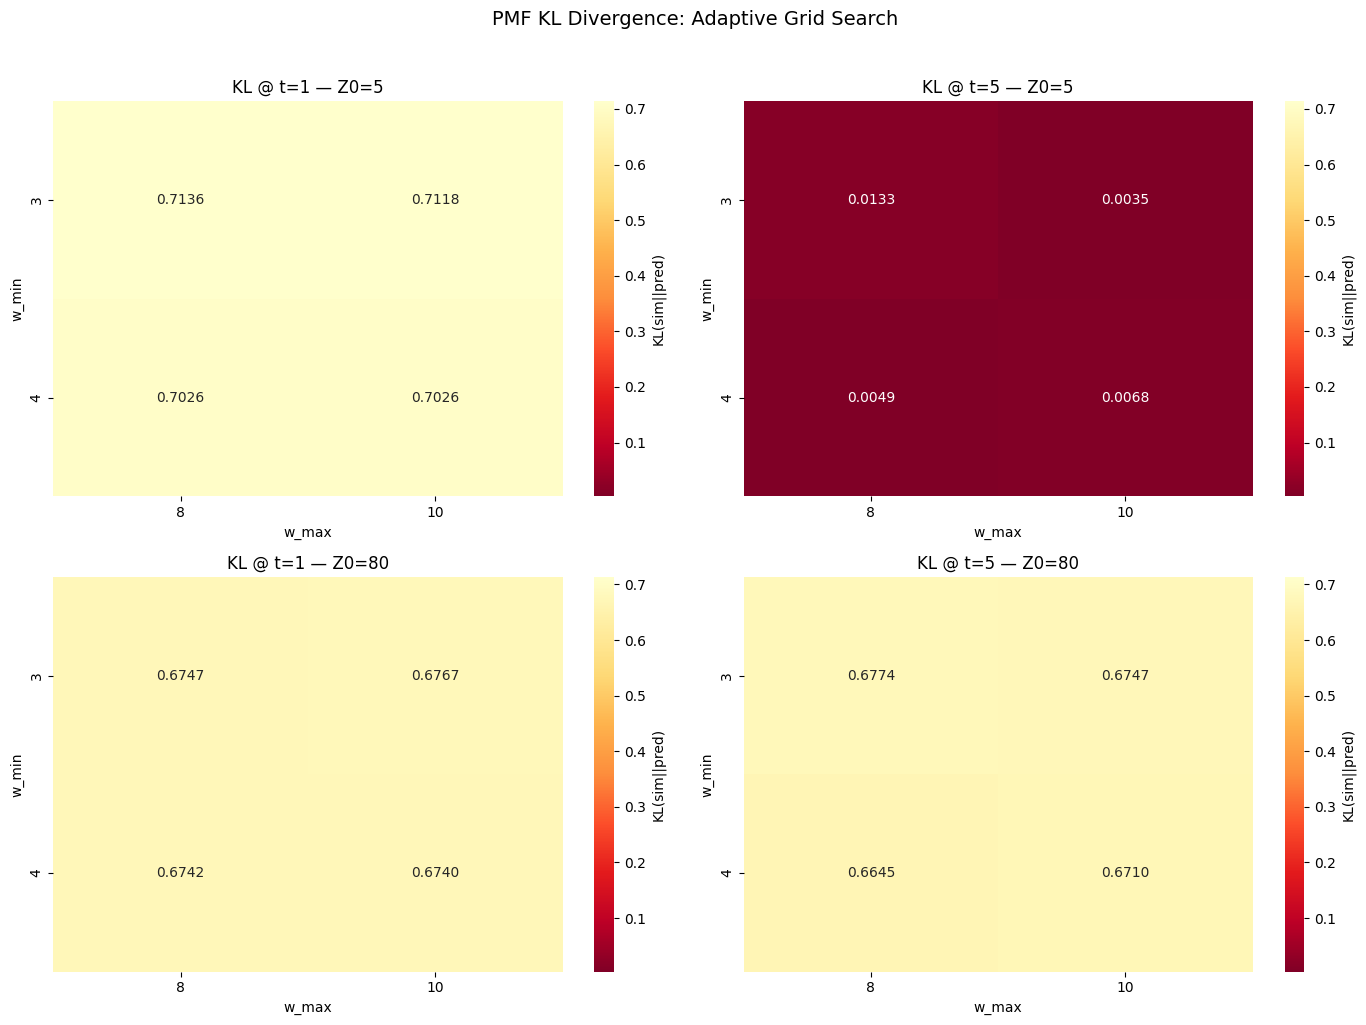

In [19]:
# --- Heatmap: KL divergence by (w_min, w_max) — split by Z0, t=1 and t=5 ---
# Compute shared color scale across all 4 subplots
all_kl = []
for t_label in ['kl_t1', 'kl_t5']:
    for z0_val in [5, 80]:
        vals = df[df['z0'] == z0_val].groupby(['w_min', 'w_max'])[t_label].mean().dropna().values
        all_kl.extend(vals)
vmin, vmax = min(all_kl), max(all_kl)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, (t_label, t_val) in enumerate([('kl_t1', 1), ('kl_t5', 5)]):
    for row, z0_val in enumerate([5, 80]):
        ax = axes[row, col]
        sub = df[df['z0'] == z0_val].groupby(['w_min', 'w_max'])[t_label].mean().reset_index()
        pivot = sub.pivot(index='w_min', columns='w_max', values=t_label)
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=ax,
                    vmin=vmin, vmax=vmax,
                    cbar_kws={'label': 'KL(sim||pred)'})
        ax.set_title(f'KL @ t={t_val} \u2014 Z0={z0_val}')
        ax.set_xlabel('w_max'); ax.set_ylabel('w_min')
plt.suptitle('PMF KL Divergence: Adaptive Grid Search', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'kl_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# --- Compare adaptive vs fixed window baseline ---
fixed_ws_list = [3, 4, 5, 8, 10, 12, 15]
baseline_results = []

for file, z0 in all_files:
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    mu = 10 if z0 == 5 else 100

    for ws in fixed_ws_list:
        try:
            # Fixed window = run_adaptive with ws_min == ws_max
            res = run_adaptive(data_raw.copy(), mu=mu, t_target=5, m=1, N=300,
                               ws_min=ws, ws_max=ws,
                               lookback=LOOKBACK, bocpd_params=BOCPD_PARAMS)
            kl_t1, _ = compute_pmf_kl(res, z0, t_obs=1)
            kl_t5, _ = compute_pmf_kl(res, z0, t_obs=5)
            baseline_results.append({
                'file': file, 'z0': z0, 'window_size': ws,
                'mse': res['mse'], 'mae': res['mae'], 'rmse': res['rmse'],
                'kl_t1': kl_t1, 'kl_t5': kl_t5,
            })
        except Exception as e:
            print(f'  Baseline ERROR: ws={ws}, {file} -> {e}')

df_baseline = pd.DataFrame(baseline_results)
print(f'Baseline runs: {len(df_baseline)}')
df_baseline


Baseline runs: 14


,file,z0,window_size,mse,mae,rmse,kl_t1,kl_t5
0,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,3,4.518006,1.605512,2.125560,0.713623,0.004572
1,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,4,5.168604,1.684727,2.273456,0.702588,0.002761
2,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,5,9.024147,2.222801,3.004022,0.700023,0.004590
3,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,8,10.912880,2.490511,3.303465,0.730723,0.000455
4,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,10,14.877029,3.001319,3.857075,0.716511,0.036261
5,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,12,14.716198,2.936575,3.836170,0.702023,0.000641
6,initial_value_5_samples_500_a_0.3_b_80_delta_1...,5,15,27.851142,3.803208,5.277418,0.701985,0.011503
7,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,3,7.576123,2.087338,2.752476,0.677334,0.668513
8,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,4,9.080163,2.307942,3.013331,0.672842,0.669161
9,initial_value_80_samples_500_a_0.3_b_80_delta_...,80,5,10.033956,2.391721,3.167642,0.668757,0.679523


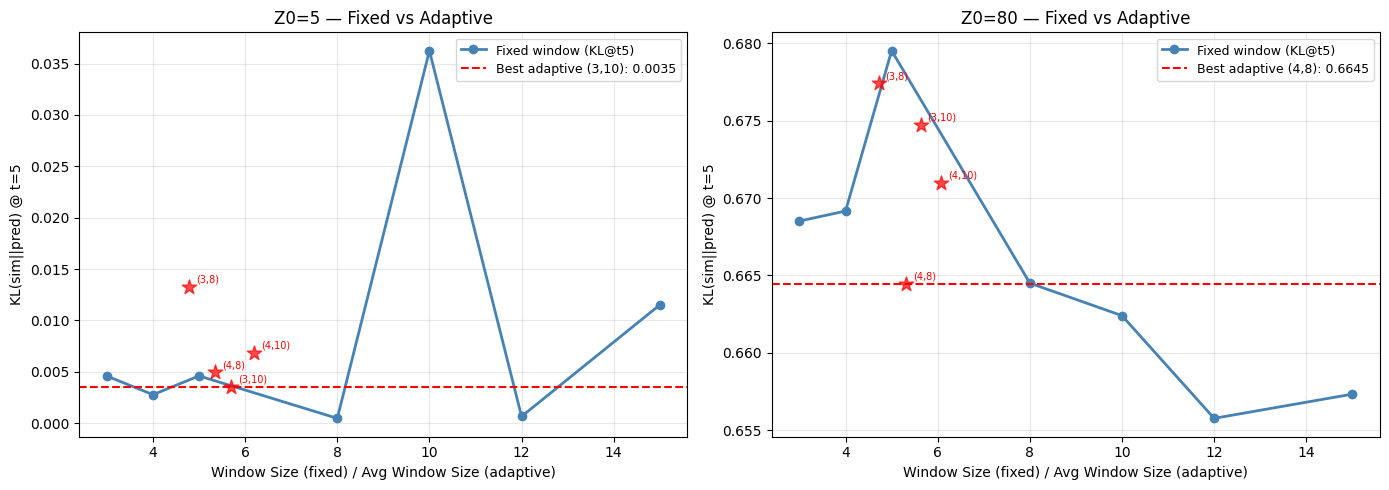

In [21]:
# --- Comparison plot: best adaptive vs all fixed, per Z0 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, z0_val in zip(axes, [5, 80]):
    # Fixed baseline
    fb = df_baseline[df_baseline['z0'] == z0_val].groupby('window_size')['kl_t5'].mean()
    ax.plot(fb.index, fb.values, 'o-', color='steelblue',
            label='Fixed window (KL@t5)', linewidth=2, markersize=6)

    # Adaptive configs
    adap = df[df['z0'] == z0_val].groupby(['w_min', 'w_max']).agg(
        kl_t5=('kl_t5', 'mean'), avg_ws=('avg_window_size', 'mean')
    )
    best_idx = adap['kl_t5'].idxmin()
    best_kl = adap['kl_t5'].min()
    ax.axhline(y=best_kl, color='red', ls='--', lw=1.5,
               label=f'Best adaptive ({best_idx[0]},{best_idx[1]}): {best_kl:.4f}')

    for (wmin, wmax), row in adap.iterrows():
        ax.scatter(row['avg_ws'], row['kl_t5'], marker='*', s=120, color='red',
                   zorder=5, alpha=0.7)
        ax.annotate(f'({wmin},{wmax})', (row['avg_ws'], row['kl_t5']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7, color='red')

    ax.set_xlabel('Window Size (fixed) / Avg Window Size (adaptive)')
    ax.set_ylabel('KL(sim||pred) @ t=5')
    ax.set_title(f'Z0={z0_val} — Fixed vs Adaptive')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fixed_vs_adaptive_kl.png'), dpi=150, bbox_inches='tight')
plt.show()


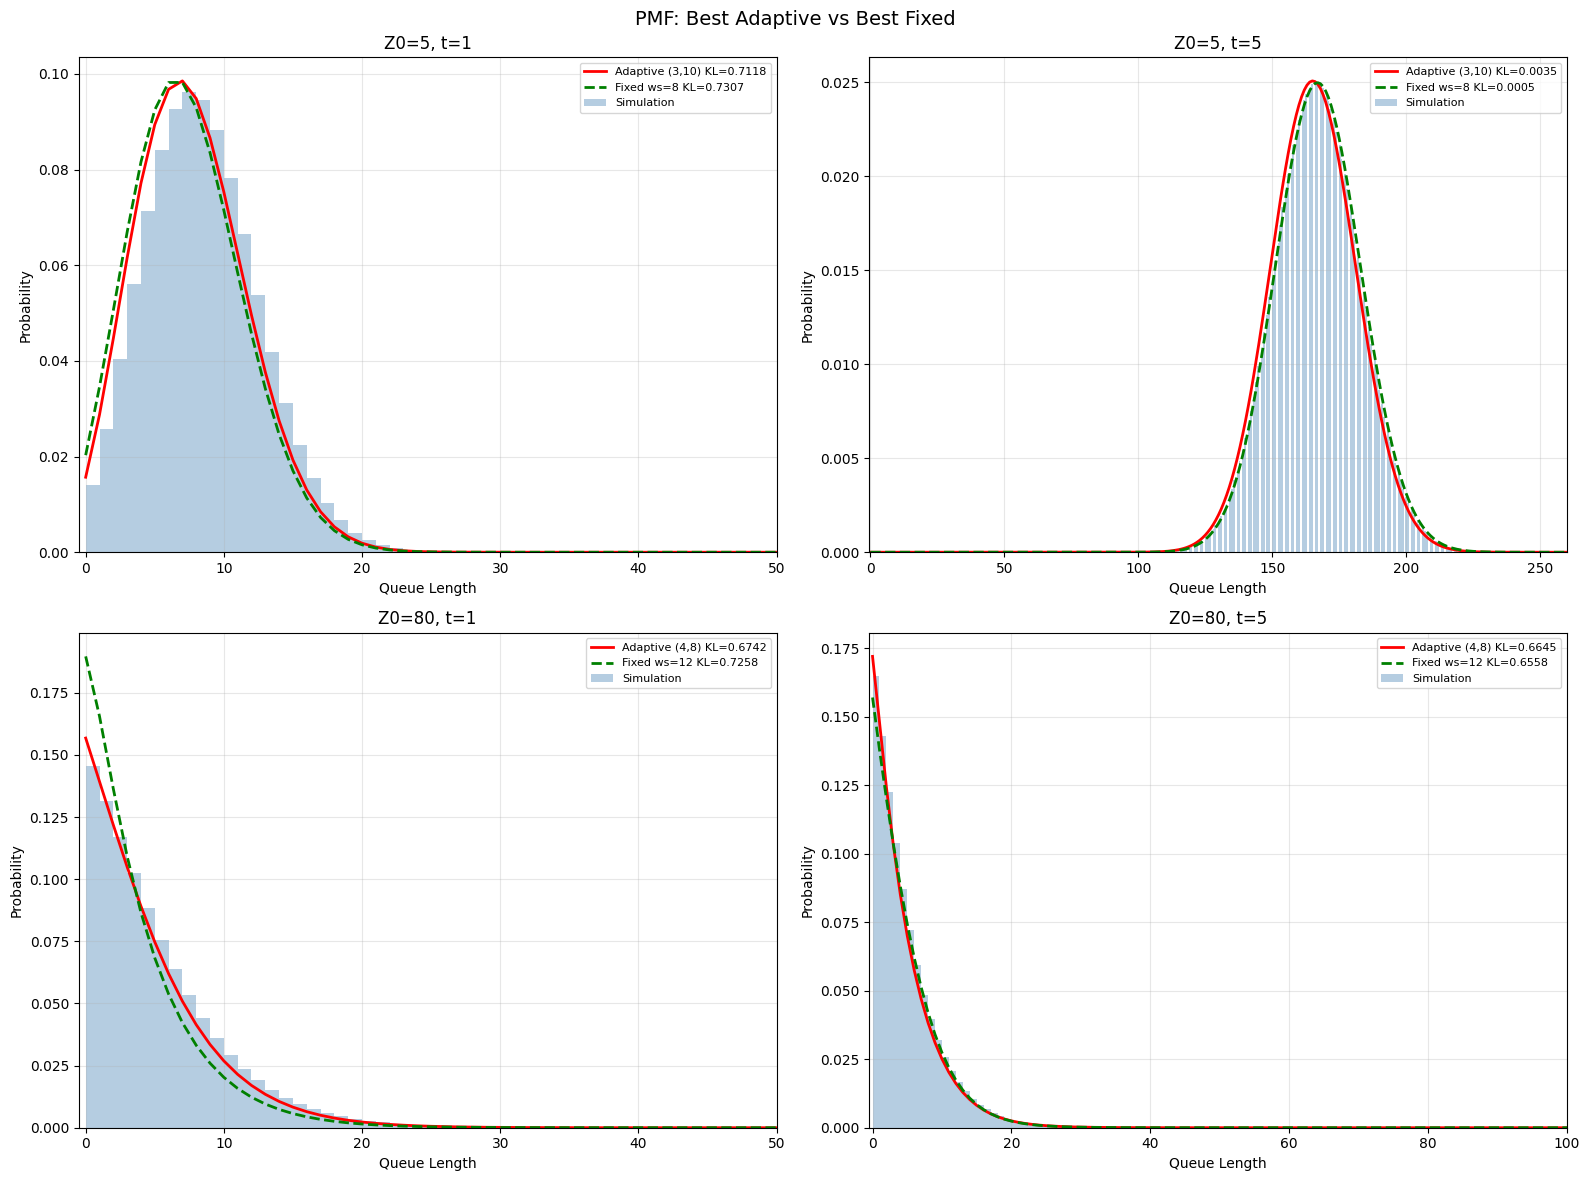

In [22]:
# --- PMF overlay: best adaptive vs best fixed per Z0 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, z0_val in enumerate([5, 80]):
    file = [f for f, z in all_files if z == z0_val][0]
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    mu = 10 if z0_val == 5 else 100

    # Best adaptive
    sub = df[df['z0'] == z0_val]
    best = sub.loc[sub['kl_t5'].idxmin()]
    w_min_best, w_max_best = int(best['w_min']), int(best['w_max'])
    res_adap = run_adaptive(data_raw.copy(), mu=mu, t_target=5, m=1, N=300,
                            ws_min=w_min_best, ws_max=w_max_best,
                            lookback=LOOKBACK, bocpd_params=BOCPD_PARAMS)

    # Best fixed
    fb = df_baseline[df_baseline['z0'] == z0_val]
    best_f = fb.loc[fb['kl_t5'].idxmin()]
    ws_fixed = int(best_f['window_size'])
    res_fixed = run_adaptive(data_raw.copy(), mu=mu, t_target=5, m=1, N=300,
                             ws_min=ws_fixed, ws_max=ws_fixed,
                             lookback=LOOKBACK, bocpd_params=BOCPD_PARAMS)

    for col, t_obs in enumerate([1, 5]):
        ax = axes[row, col]
        N_pmf = 300

        # Load simulation histogram (original bins)
        centers, probs, widths = load_sim_hist(z0_val, t_obs)

        # Predicted PMFs
        _, pmf_adap = compute_pmf_kl(res_adap, z0_val, t_obs, N=N_pmf)
        _, pmf_fixed = compute_pmf_kl(res_fixed, z0_val, t_obs, N=N_pmf)

        # Build integer-grid version for KL
        sim_grid = np.zeros(N_pmf)
        for c_, p_ in zip(centers, probs):
            ix = int(round(c_))
            if 0 <= ix < N_pmf:
                sim_grid[ix] += p_

        # Plot simulation histogram with original bins
        ax.bar(centers, probs, width=widths, alpha=0.4, color='steelblue',
               edgecolor='none', label='Simulation')

        # Overlay predicted PMFs
        if pmf_adap is not None:
            kl_a = calculate_kl_divergence(sim_grid, pmf_adap)
            ax.plot(np.arange(min(len(pmf_adap), N_pmf)), pmf_adap[:N_pmf],
                    'r-', lw=2, label=f'Adaptive ({w_min_best},{w_max_best}) KL={kl_a:.4f}')
        if pmf_fixed is not None:
            kl_f = calculate_kl_divergence(sim_grid, pmf_fixed)
            ax.plot(np.arange(min(len(pmf_fixed), N_pmf)), pmf_fixed[:N_pmf],
                    'g--', lw=2, label=f'Fixed ws={ws_fixed} KL={kl_f:.4f}')

        xlim_map = {(5,1): 50, (5,5): 260, (80,1): 50, (80,5): 100}
        ax.set_xlim(-0.5, xlim_map.get((z0_val, t_obs), 50))
        ax.set_title(f'Z0={z0_val}, t={t_obs}')
        ax.set_xlabel('Queue Length'); ax.set_ylabel('Probability')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('PMF: Best Adaptive vs Best Fixed', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pmf_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()


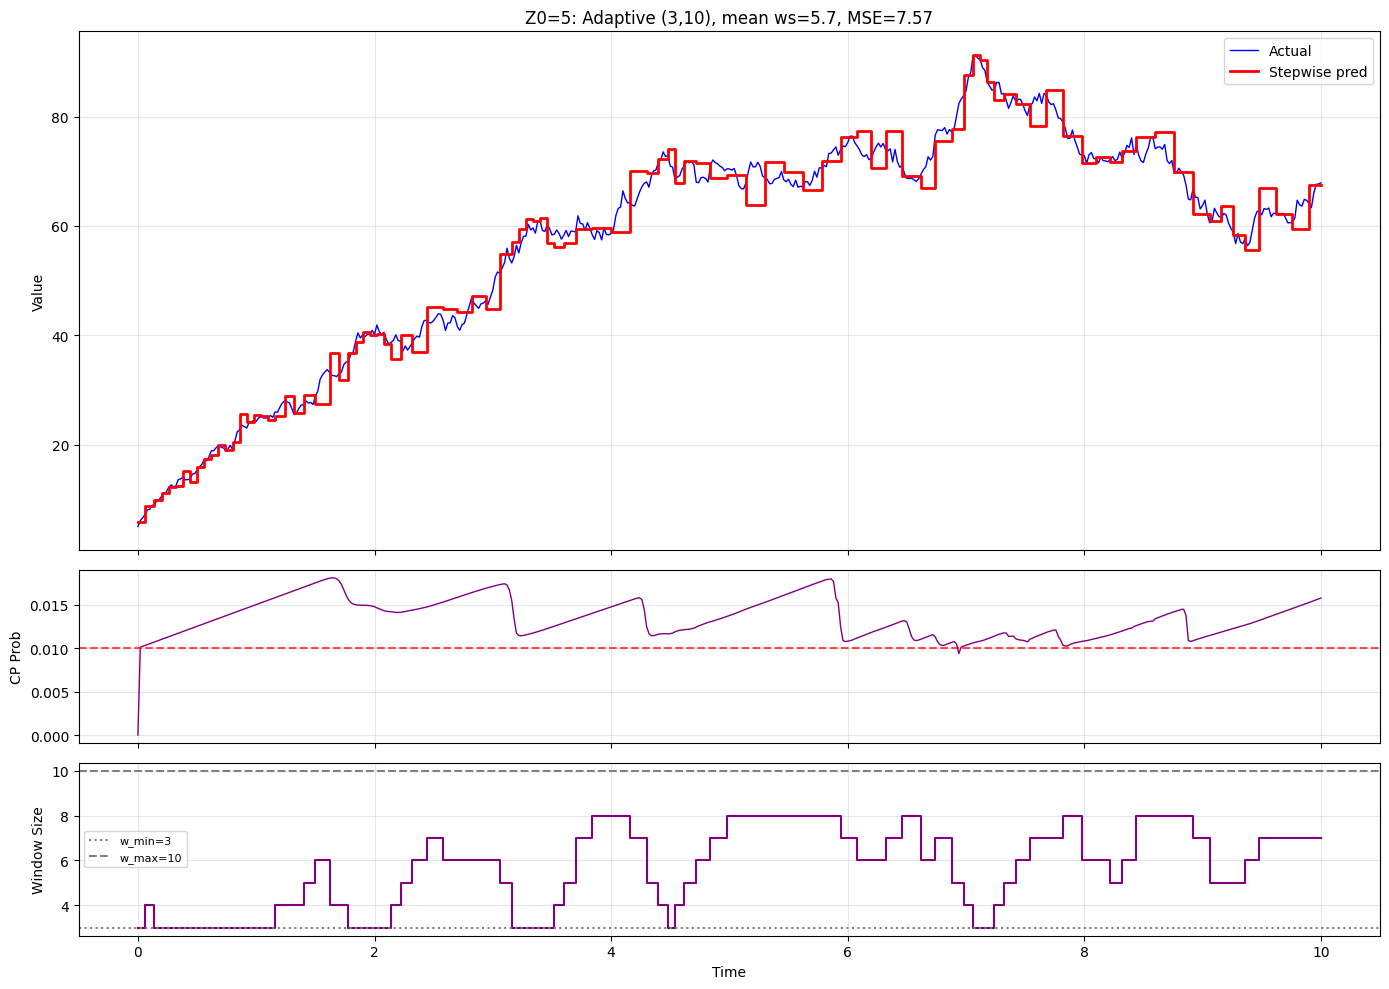

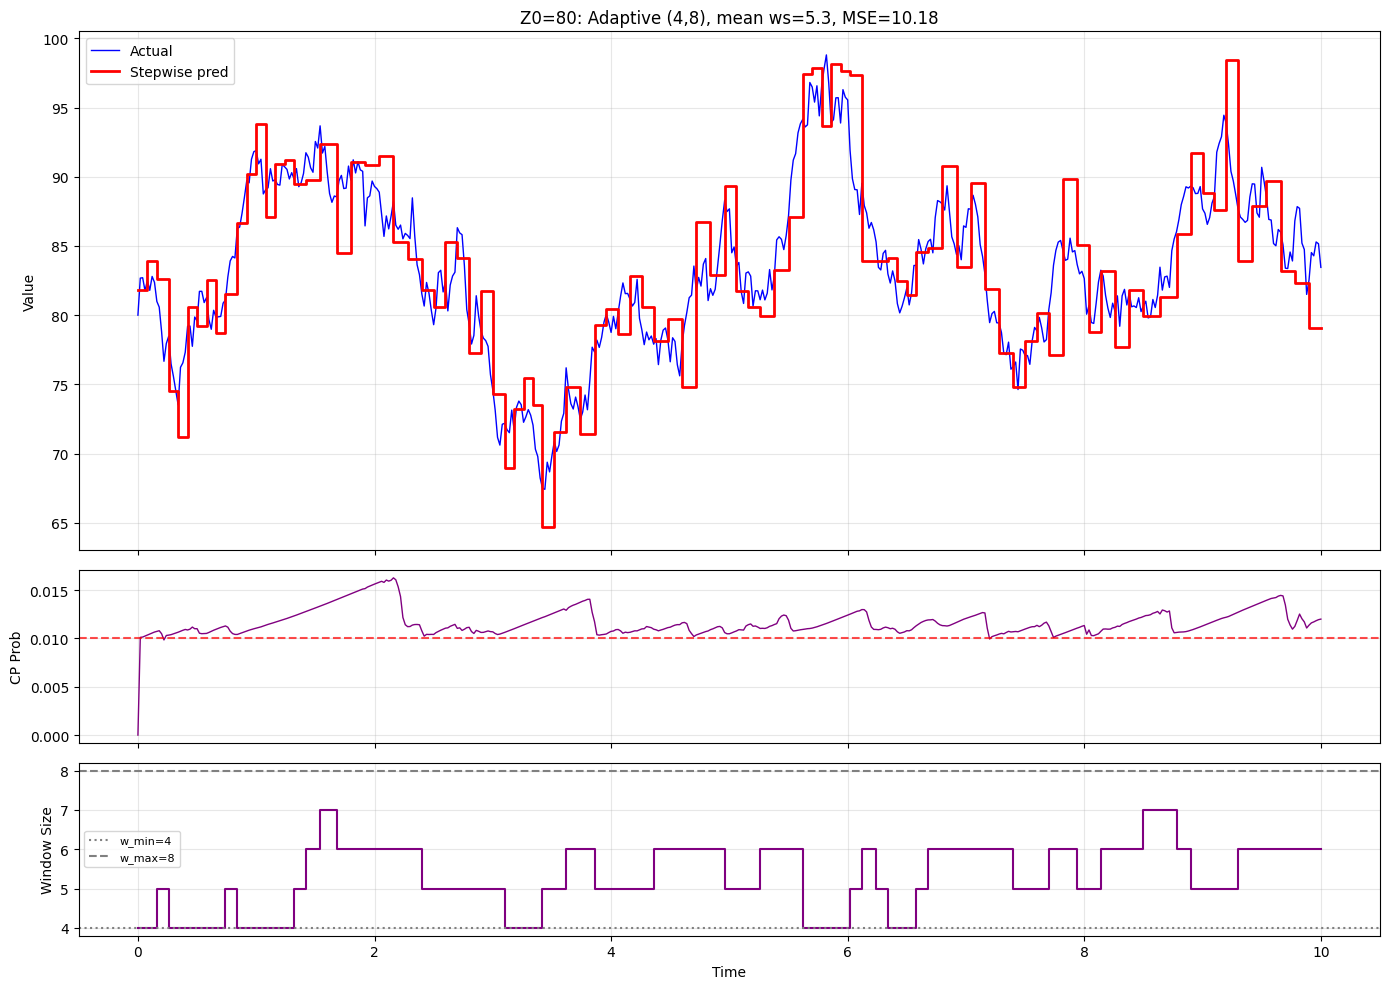

In [23]:
# --- Visualize best adaptive: predictions + window sizes ---
for z0_val in [5, 80]:
    file = [f for f, z in all_files if z == z0_val][0]
    data_raw = pd.read_csv(os.path.join(ARRIVAL_DIR, file))
    mu = 10 if z0_val == 5 else 100

    sub = df[df['z0'] == z0_val]
    best = sub.loc[sub['kl_t5'].idxmin()]
    w_min_best, w_max_best = int(best['w_min']), int(best['w_max'])

    res = run_adaptive(data_raw.copy(), mu=mu, t_target=5, m=1, N=300,
                       ws_min=w_min_best, ws_max=w_max_best,
                       lookback=LOOKBACK, bocpd_params=BOCPD_PARAMS)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                         height_ratios=[3, 1, 1], sharex=True)
    ax1.plot(res['times'], res['values'], 'b-', lw=1, label='Actual')
    ax1.step(res['times'], res['stepwise'], 'r-', lw=2, where='post', label='Stepwise pred')
    ax1.set_title(f'Z0={z0_val}: Adaptive ({w_min_best},{w_max_best}), '
                  f'mean ws={res["mean_ws"]:.1f}, MSE={res["mse"]:.2f}')
    ax1.set_ylabel('Value'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(res['times'], res['cp_probs'], 'purple', lw=1)
    ax2.axhline(BOCPD_PARAMS['alarm_threshold'], color='red', ls='--', alpha=0.7)
    ax2.set_ylabel('CP Prob'); ax2.grid(True, alpha=0.3)

    ax3.step(res['times'], res['ws_used'], 'purple', lw=1.5, where='post')
    ax3.axhline(w_min_best, color='gray', ls=':', label=f'w_min={w_min_best}')
    ax3.axhline(w_max_best, color='gray', ls='--', label=f'w_max={w_max_best}')
    ax3.set_ylabel('Window Size'); ax3.set_xlabel('Time')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f'viz_Z0={z0_val}.png'), dpi=150, bbox_inches='tight')
    plt.show()


In [24]:
# --- Final summary ---
print('='*60)
print('RESULTS: a=0.3, b=80 (rolling-std adaptive window)')
print('='*60)

for z0_val in [5, 80]:
    print(f'\n--- Z0 = {z0_val} ---')
    sub = df[df['z0'] == z0_val].sort_values('kl_t5')
    print(sub[['w_min', 'w_max', 'mse', 'mae', 'avg_window_size', 'kl_t1', 'kl_t5']].to_string(index=False))

    fb = df_baseline[df_baseline['z0'] == z0_val]
    if len(fb) > 0:
        best_fixed = fb.loc[fb['kl_t5'].idxmin()]
        best_adap = sub.iloc[0]

        imp_mse = (best_fixed['mse'] - best_adap['mse']) / best_fixed['mse'] * 100
        imp_kl = (best_fixed['kl_t5'] - best_adap['kl_t5']) / best_fixed['kl_t5'] * 100

        print(f'\n  [MSE] Best fixed: ws={int(best_fixed["window_size"])}, MSE={best_fixed["mse"]:.2f}')
        print(f'  [MSE] Best adaptive: ({int(best_adap["w_min"])},{int(best_adap["w_max"])}), MSE={best_adap["mse"]:.2f}, Improvement: {imp_mse:+.1f}%')
        print(f'  [KL@t5] Best fixed: ws={int(best_fixed["window_size"])}, KL={best_fixed["kl_t5"]:.4f}')
        print(f'  [KL@t5] Best adaptive: ({int(best_adap["w_min"])},{int(best_adap["w_max"])}), KL={best_adap["kl_t5"]:.4f}, Improvement: {imp_kl:+.1f}%')


RESULTS: a=0.3, b=80 (rolling-std adaptive window)

--- Z0 = 5 ---
 w_min  w_max      mse      mae  avg_window_size    kl_t1    kl_t5
     3     10 7.567620 2.046907         5.686627 0.711782 0.003497
     4      8 7.715178 2.063275         5.347305 0.702588 0.004926
     4     10 8.917473 2.168769         6.199601 0.702588 0.006824
     3      8 8.245555 2.113041         4.788423 0.713623 0.013279

  [MSE] Best fixed: ws=8, MSE=10.91
  [MSE] Best adaptive: (3,10), MSE=7.57, Improvement: +30.7%
  [KL@t5] Best fixed: ws=8, KL=0.0005
  [KL@t5] Best adaptive: (3,10), KL=0.0035, Improvement: -667.9%

--- Z0 = 80 ---
 w_min  w_max       mse      mae  avg_window_size    kl_t1    kl_t5
     4      8 10.178720 2.422821         5.307385 0.674195 0.664475
     4     10  8.182601 2.161185         6.081836 0.674033 0.670977
     3     10 14.086347 2.877883         5.626747 0.676696 0.674732
     3      8 10.836501 2.464982         4.716567 0.674707 0.677417

  [MSE] Best fixed: ws=12, MSE=19.59
  